# Supplemental Figure S27-S28: DMS-informed distance constraints improve Rosetta modeling of RNA motifs with A-G pairs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from dms_3d_features.plotting import (
    plot_pop_avg_from_row,
    publication_style_ax,
    plot_violins_w_percent,
    plot_motif_boxplot_stripplot,
)

In [2]:
FARFAR_PATH = "../../farfar-models"

In [3]:
df_train = pd.read_csv(f"{FARFAR_PATH}/csvs/ag_pair_train_analysis.csv")

/var/folders/jb/h5qjq4n15qg56r7dptdffxch5f0py6/T/ipykernel_14020/1580494023.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(new_labels)


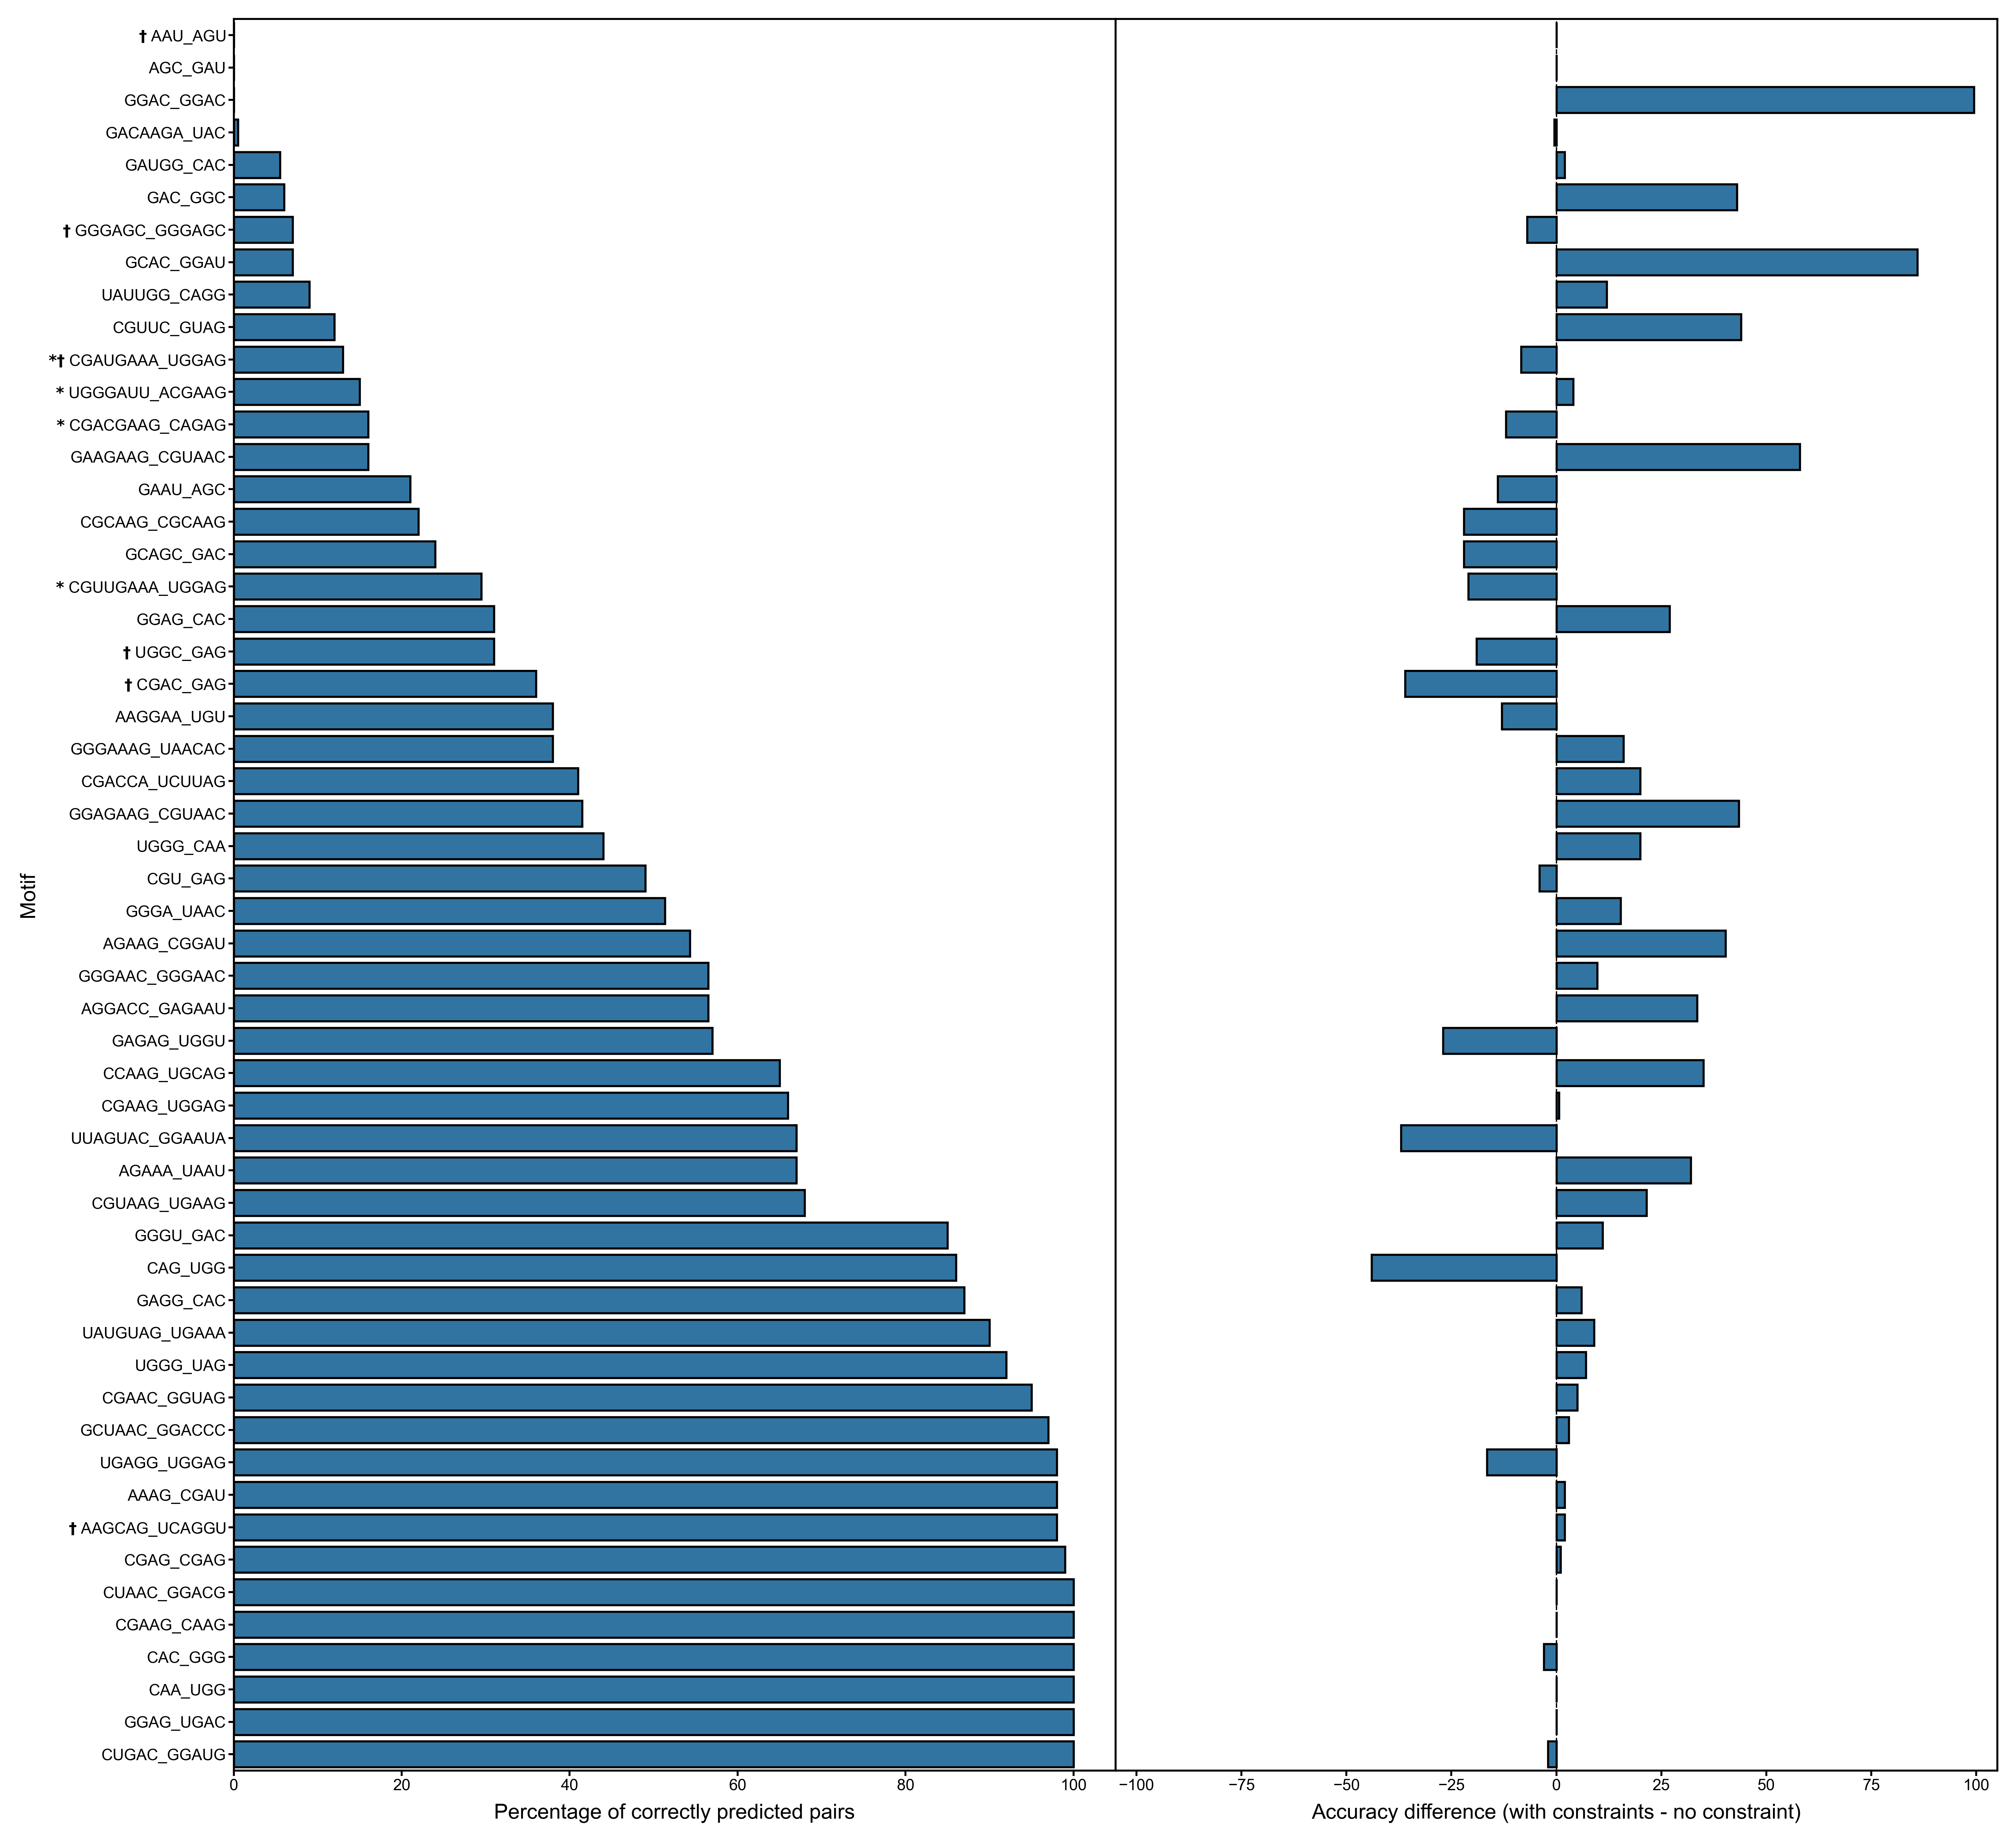

In [ ]:
kink_turns = [
    "CGACGAAG_CAGAG",
    "CGAUGAAA_UGGAG",
    "CGUUGAAA_UGGAG",
    "UGGGAUU_ACGAAG"
]

data_outliers = [
    "CGAC_GAG",
    "CGAUGAAA_UGGAG",
    "GGGAGC_GGGAGC",
    "UGGC_GAG",
    "AAGCAG_UCAGGU",
    "AAU_AGU"
]

# -----------------------------------
# SORT by WITH constraint (ascending)
# -----------------------------------
df_sorted = df_train.sort_values(
    by="percent_true_no_cst",

)
motif_order = df_sorted["motif"].tolist()
# -----------------------------------
# FIGURE with shared Y-axis
# -----------------------------------
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 12),
    sharey=True,
    gridspec_kw={"wspace": 0},
    dpi = 600
)

# -----------------------------------
# COLOR PALETTE (no category ordering)
# -----------------------------------
#palette = sns.color_palette("tab20", n_colors=df_sorted["category"].nunique())

# -----------------------------------
# LEFT PLOT → WITH CONSTRAINT
# -----------------------------------
sns.barplot(
    data=df_sorted,
    x="percent_true_no_cst",
    y="motif", 
    dodge=False,
    ax=ax1,
    edgecolor="black", 
    linewidth=0.8
)

ax1.set_xlabel("Percentage of correctly predicted pairs")
ax1.set_ylabel("Motif")

# -----------------------------------
# RIGHT PLOT → DIFFERENCE (same as before)
# -----------------------------------
sns.barplot(
    data=df_sorted,
    x="percent_true_pair_diff",
    y="motif",
    dodge=False,
    ax=ax2,
    edgecolor="black", 
    linewidth=0.8
)

ax2.set_xlabel("Accuracy difference (with constraints - no constraint)")
ax2.set_ylabel("")  # remove duplicate label

# -----------------------------------
# REMOVE duplicate legends (keep only one)
# -----------------------------------
legend = ax2.get_legend()
if legend is not None:
    legend.remove()

# -----------------------------------
# MODIFY Y-TICK LABELS (INLINE SYMBOLS)
# -----------------------------------
new_labels = []

for motif in motif_order:

    if motif in kink_turns and motif in data_outliers:
        label = r"$\mathbf{*†}$ " + motif
    elif motif in kink_turns:
        label = r"$\mathbf{*}$ " + motif
    elif motif in data_outliers:
        label = r"$\mathbf{†}$ " + motif
    else:
        label = motif

    new_labels.append(label)

ax1.set_yticklabels(new_labels)

# -----------------------------------
# REFERENCE LINE (only on diff plot)
# -----------------------------------
ax2.axvline(0, linestyle="--", linewidth=0.5, color="black")
ax2.set_xlim(-105, 105)
ax2.tick_params(axis='y', left=False, labelleft=False)

# -----------------------------------
# FINAL LAYOUT
# -----------------------------------
publication_style_ax(ax1)
publication_style_ax(ax2)
plt.show()
fig.savefig(
    "../../pngs/supplemental_figures/supplemental_figure_s28.png",
    dpi=600,
    bbox_inches="tight",
)

In [5]:
df_test = pd.read_csv(f"{FARFAR_PATH}/csvs/ag_pair_test_analysis.csv")

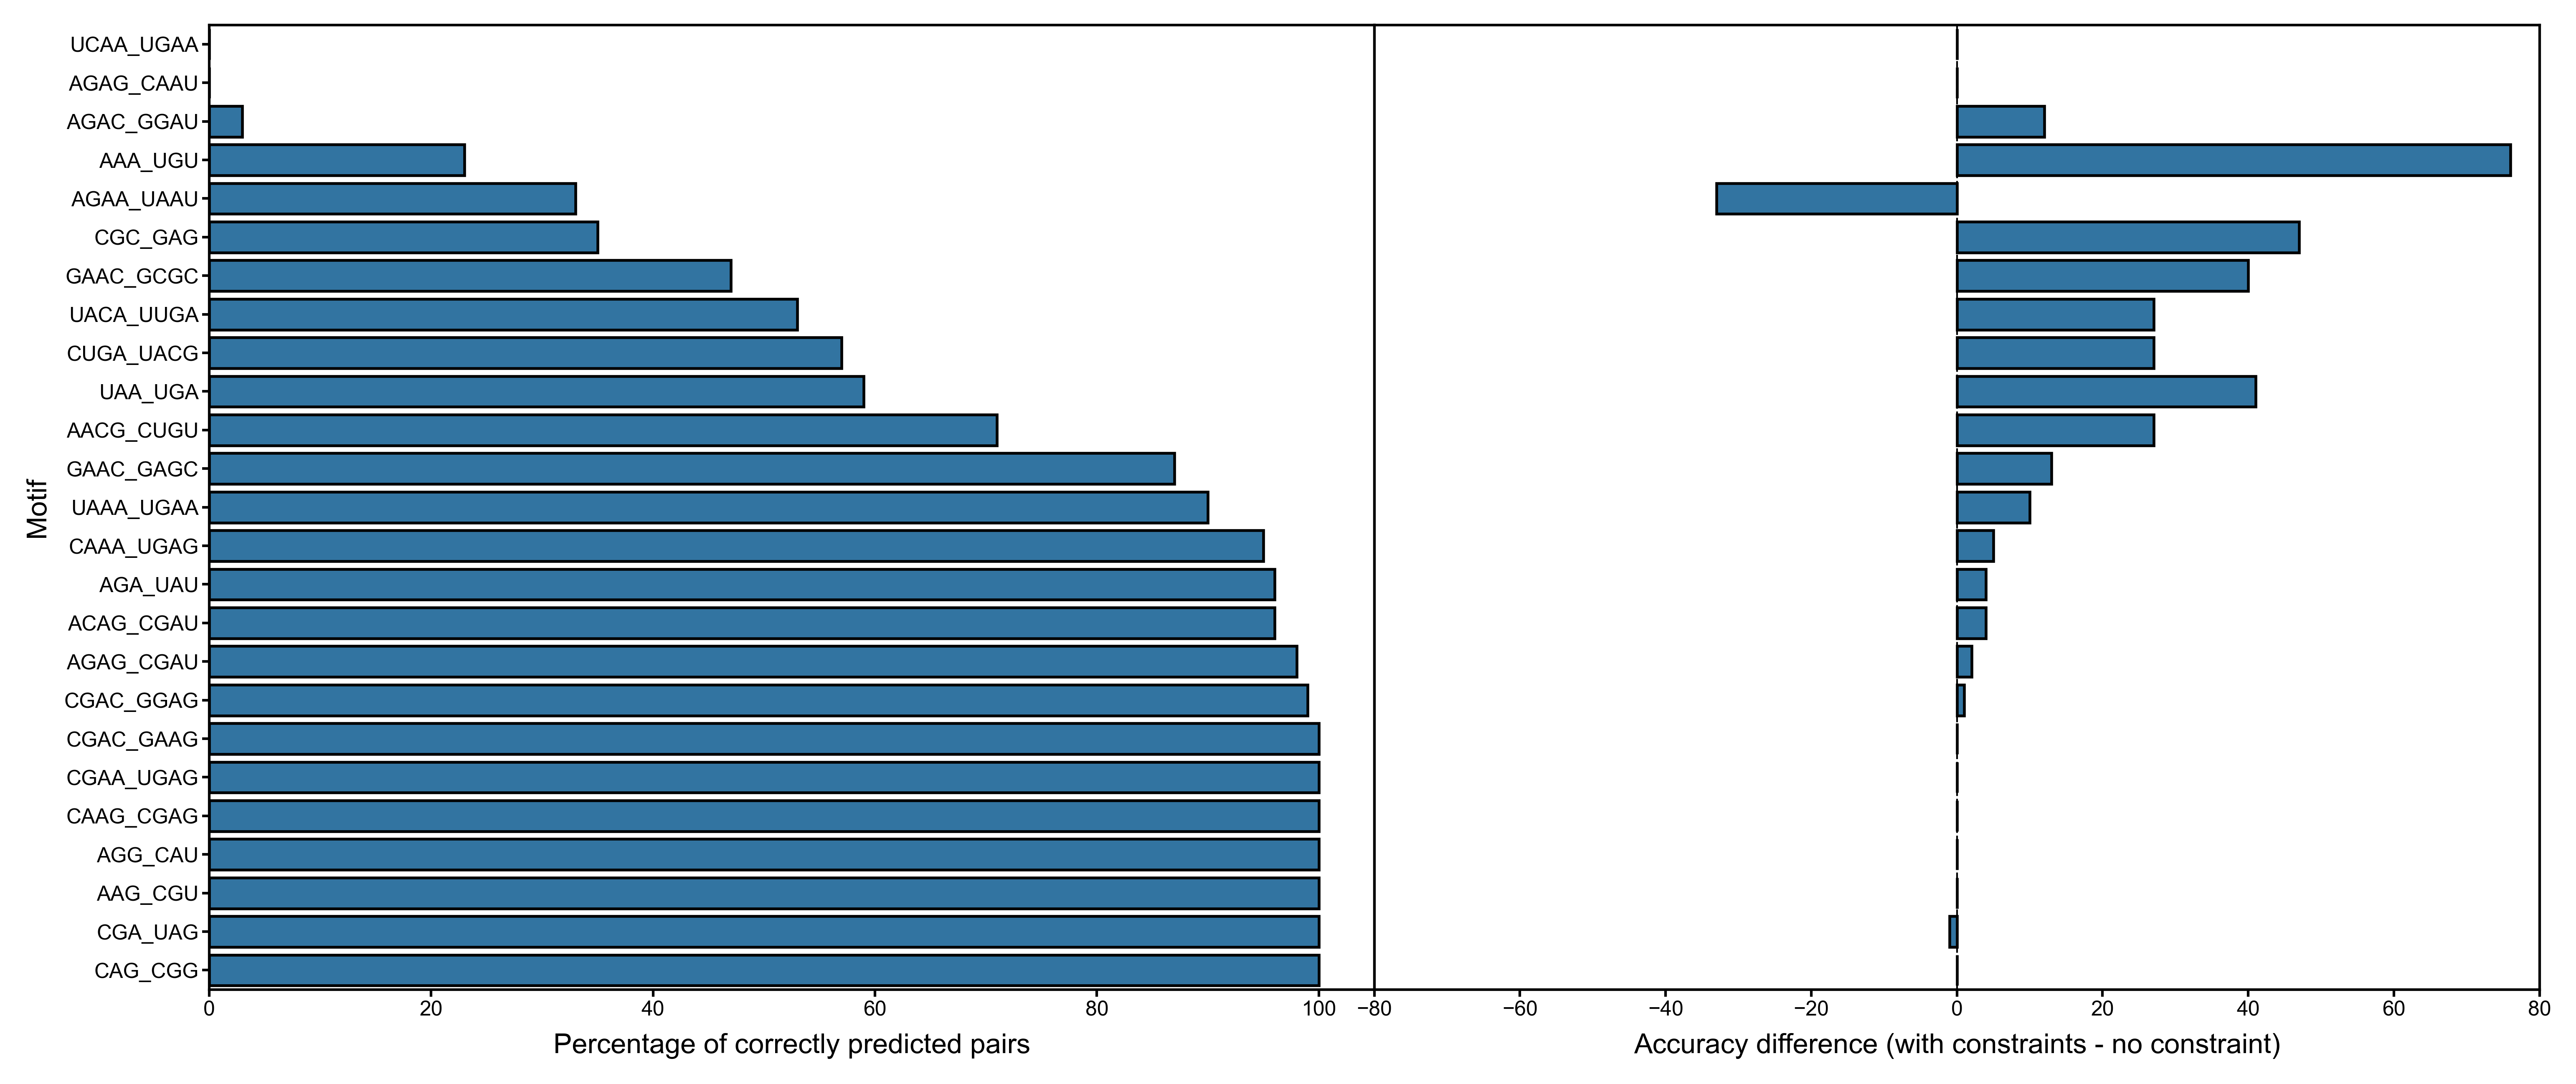

In [ ]:
# -----------------------------------
# SORT by WITH constraint (ascending)
# -----------------------------------
df_sorted = df_test.sort_values(
    by="percent_true_no_cst",

)
motif_order = df_sorted["motif"].tolist()
# -----------------------------------
# FIGURE with shared Y-axis
# -----------------------------------
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5),
    sharey=True,
    gridspec_kw={"wspace": 0},
    dpi = 600
)

# -----------------------------------
# LEFT PLOT → WITH CONSTRAINT
# -----------------------------------
sns.barplot(
    data=df_sorted,
    x="percent_true_no_cst",
    y="motif", 
    dodge=False,
    ax=ax1,
    edgecolor="black", 
    linewidth=0.8
)

ax1.set_xlabel("Percentage of correctly predicted pairs")
ax1.set_ylabel("Motif")

# -----------------------------------
# RIGHT PLOT → DIFFERENCE (same as before)
# -----------------------------------
sns.barplot(
    data=df_sorted,
    x="percent_true_pair_diff",
    y="motif",
    dodge=False,
    ax=ax2,
    edgecolor="black", 
    linewidth=0.8
)

ax2.set_xlabel("Accuracy difference (with constraints - no constraint)")
ax2.set_ylabel("")  # remove duplicate label

# -----------------------------------
# REMOVE duplicate legends (keep only one)
# -----------------------------------
legend = ax2.get_legend()
if legend is not None:
    legend.remove()

# -----------------------------------
# REFERENCE LINE (only on diff plot)
# -----------------------------------
ax2.axvline(0, linestyle="--", linewidth=0.5, color="black")
ax2.set_xlim(-80, 80)
ax2.tick_params(axis='y', left=False, labelleft=False)
# -----------------------------------
# FINAL LAYOUT
# -----------------------------------
publication_style_ax(ax1)
publication_style_ax(ax2)
plt.show()
fig.savefig(
    "../../pngs/supplemental_figures/supplemental_figure_s29.png",
    dpi=600,
    bbox_inches="tight",
)